# Apartment Price Predictor

Задача: предсказать стоимость квартиры по характеристикам объекта недвижимости.

Тип задачи: регрессия.

Целевая переменная: price.

Основная метрика: RMSE.

In [17]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from catboost import CatBoostRegressor

In [4]:
train = pd.read_csv("data.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("solution_example_full.csv")

In [18]:
print(train.shape)
print(test.shape)

train.head()

(100000, 20)
(100000, 18)


,index,kitchen_area,bath_area,other_area,gas,hot_water,central_heating,extra_area,extra_area_count,year,ceil_height,floor_max,floor,total_area,bath_count,extra_area_type_name,district_name,rooms_count,price,target
0,0,17,34,42.876495,Yes,No,Yes,3,1,2011,3.16,12,4,94.876495,2,balcony,Moskovskij,2,28285348,1
1,1,17,12,25.487543,Yes,Yes,Yes,11,1,1908,4.68,2,2,58.154210,1,balcony,Nevskij,2,12923063,0
2,2,22,35,39.041948,No,No,Yes,9,1,1953,3.12,3,2,99.041948,2,balcony,Kirovskij,3,20463247,1
3,3,11,26,11.646696,No,Yes,Yes,5,0,2004,2.50,15,1,50.313363,2,loggia,Krasnoselskij,0,10517141,0
4,4,8,14,14.406673,No,No,Yes,18,1,1970,2.50,7,2,42.406673,1,balcony,Krasnoselskij,0,8455506,0


In [19]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   index                 100000 non-null  int64  
 1   kitchen_area          100000 non-null  int64  
 2   bath_area             100000 non-null  int64  
 3   other_area            100000 non-null  float64
 4   gas                   100000 non-null  str    
 5   hot_water             100000 non-null  str    
 6   central_heating       100000 non-null  str    
 7   extra_area            100000 non-null  int64  
 8   extra_area_count      100000 non-null  int64  
 9   year                  100000 non-null  int64  
 10  ceil_height           100000 non-null  float64
 11  floor_max             100000 non-null  int64  
 12  floor                 100000 non-null  int64  
 13  total_area            100000 non-null  float64
 14  bath_count            100000 non-null  int64  
 15  extra_area_t

In [20]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,100000.0,NaN,NaN,NaN,49999.5,28867.657797,0.0,24999.75,49999.5,74999.25,99999.0
kitchen_area,100000.0,NaN,NaN,NaN,16.49498,5.761893,7.0,11.0,16.0,21.0,26.0
bath_area,100000.0,NaN,NaN,NaN,21.48522,8.645616,7.0,14.0,21.0,29.0,36.0
other_area,100000.0,NaN,NaN,NaN,28.156113,20.403852,11.00013,12.987989,18.901809,36.874833,90.999638
gas,100000,2,No,50043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hot_water,100000,2,Yes,65042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
central_heating,100000,2,Yes,89977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
extra_area,100000.0,NaN,NaN,NaN,9.98953,5.777662,0.0,5.0,10.0,15.0,20.0
extra_area_count,100000.0,NaN,NaN,NaN,1.0016,0.707377,0.0,1.0,1.0,2.0,2.0
year,100000.0,NaN,NaN,NaN,1960.12679,34.622494,1900.0,1930.0,1960.0,1990.0,2020.0


In [9]:
train.columns.tolist()

['index',
 'kitchen_area',
 'bath_area',
 'other_area',
 'gas',
 'hot_water',
 'central_heating',
 'extra_area',
 'extra_area_count',
 'year',
 'ceil_height',
 'floor_max',
 'floor',
 'total_area',
 'bath_count',
 'extra_area_type_name',
 'district_name',
 'rooms_count',
 'price']

In [10]:
missing = train.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [13]:
print("Duplicated rows in train:", train.duplicated().sum())

Duplicated rows in train: 0


In [14]:
print("Отрицательная kitchen_area:", (train["kitchen_area"] < 0).sum())
print("Отрицательная bath_area:", (train["bath_area"] < 0).sum())
print("Отрицательная other_area:", (train["other_area"] < 0).sum())
print("floor > floor_max:", (train["floor"] > train["floor_max"]).sum())
print("rooms_count < 0:", (train["rooms_count"] < 0).sum())
print("bath_count < 0:", (train["bath_count"] < 0).sum())

Отрицательная kitchen_area: 0
Отрицательная bath_area: 0
Отрицательная other_area: 0
floor > floor_max: 0
rooms_count < 0: 0
bath_count < 0: 0


### Вывод по качеству данных
- Пропусков нет
- Дубликатов нет
- Проверены логические ограничения

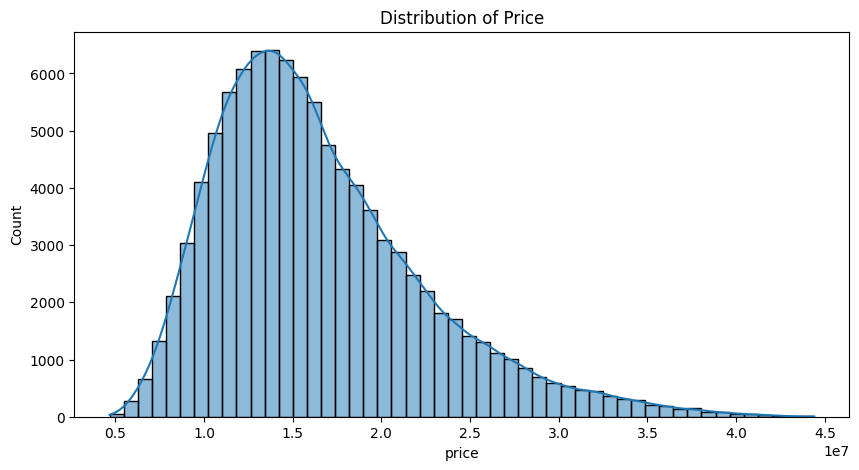

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(train["price"], bins=50, kde=True)
plt.title("Distribution of Price")
plt.show()

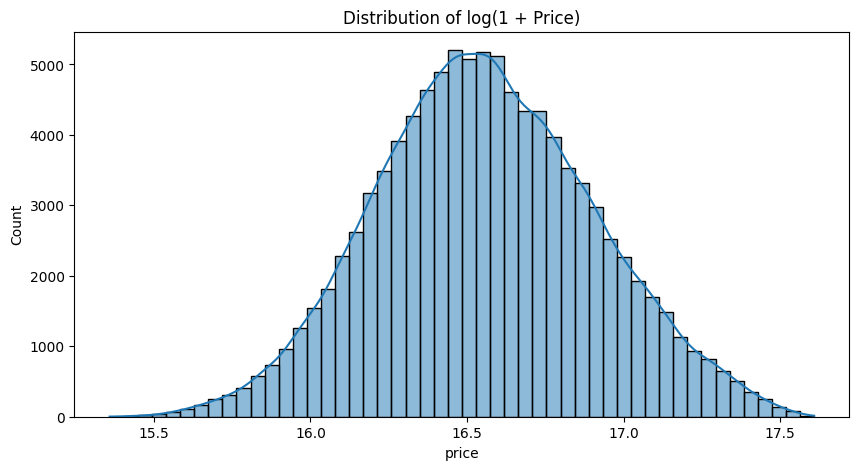

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(train["price"]), bins=50, kde=True)
plt.title("Distribution of log(1 + Price)")
plt.show()

In [24]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove("price")
num_cols

['index',
 'kitchen_area',
 'bath_area',
 'other_area',
 'extra_area',
 'extra_area_count',
 'year',
 'ceil_height',
 'floor_max',
 'floor',
 'total_area',
 'bath_count',
 'rooms_count',
 'target']

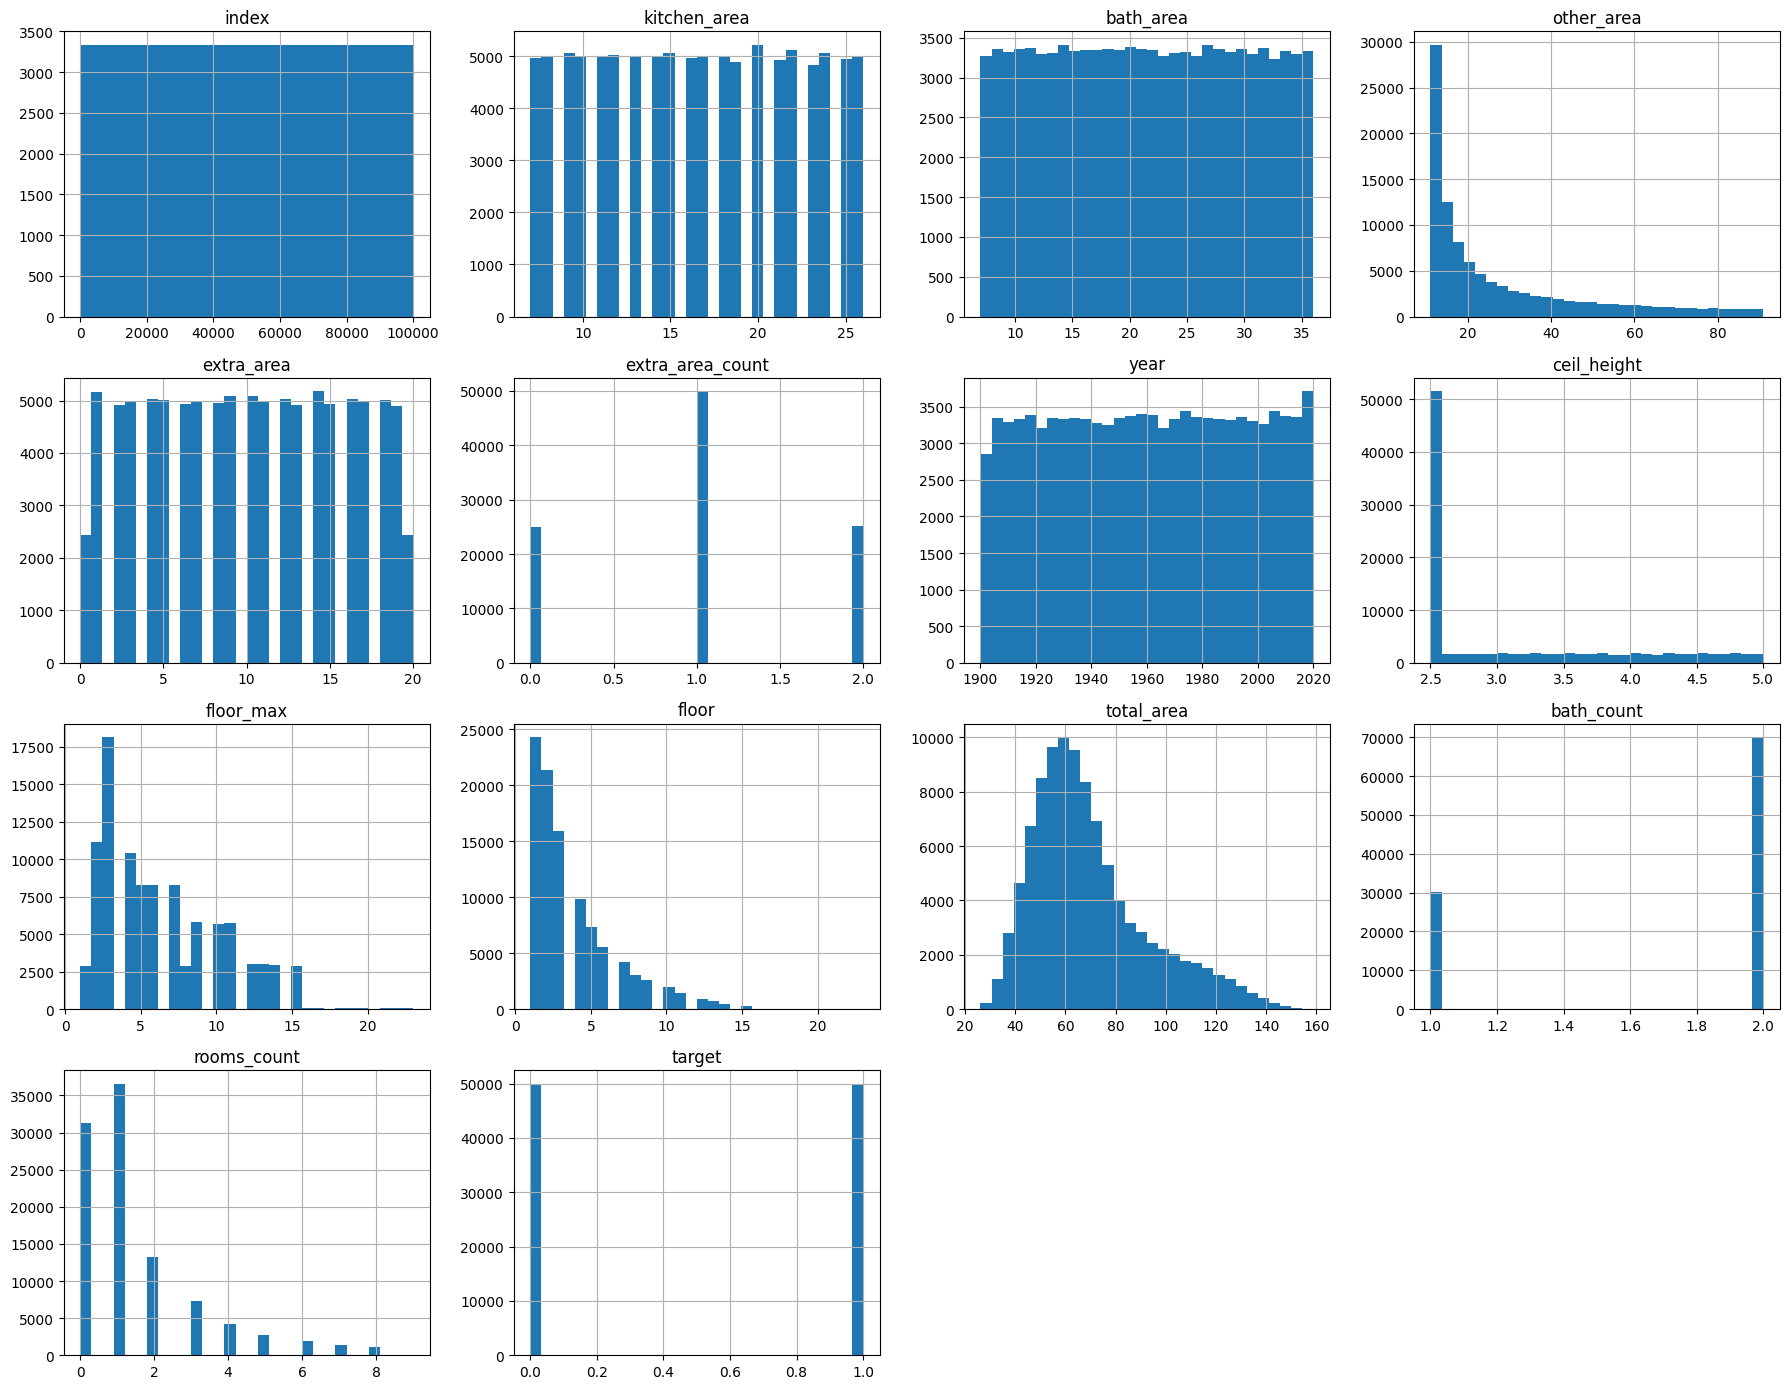

In [25]:
train[num_cols].hist(figsize=(18, 14), bins=30)
plt.tight_layout()
plt.show()

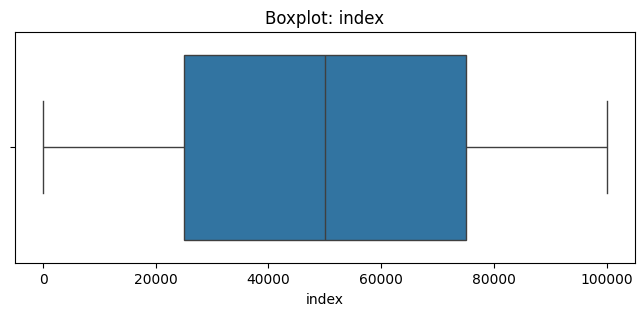

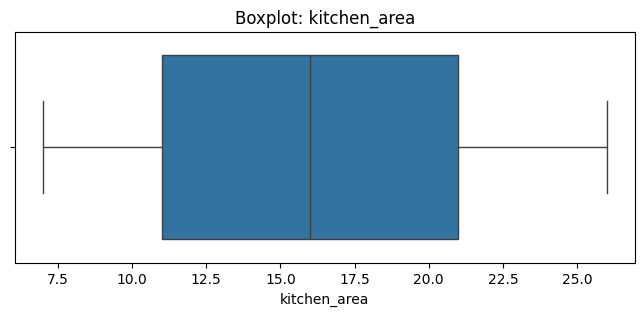

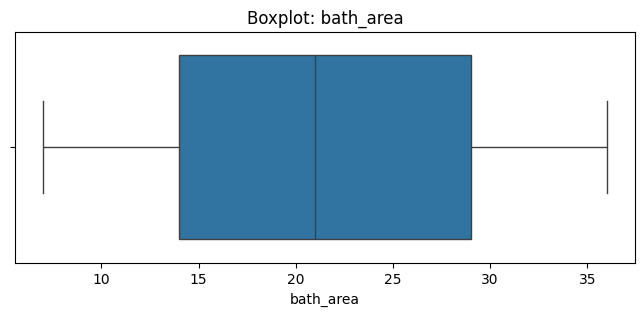

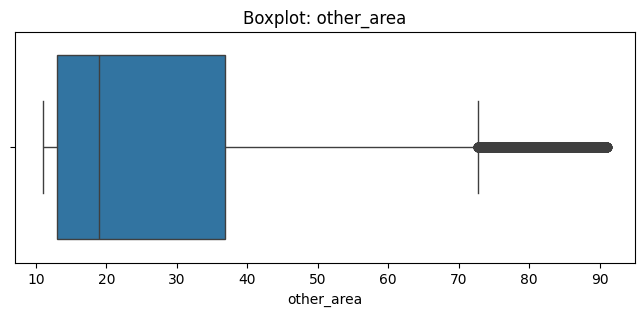

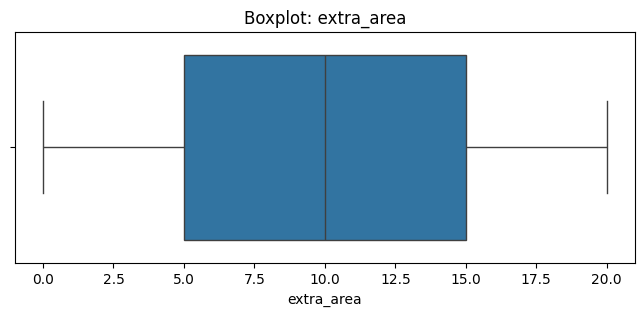

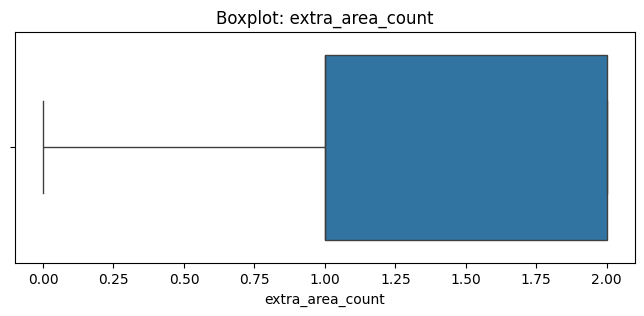

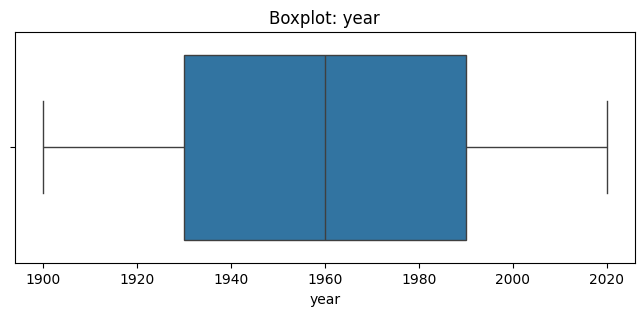

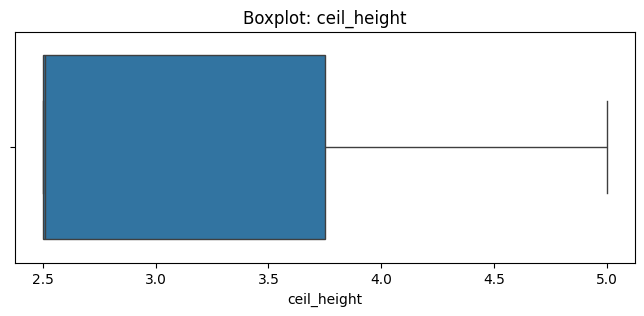

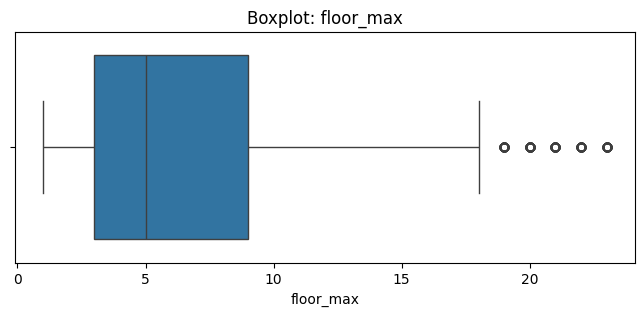

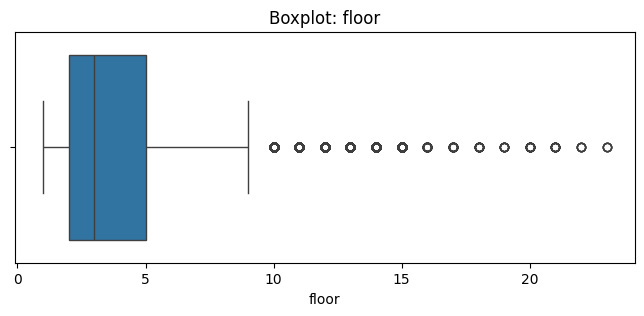

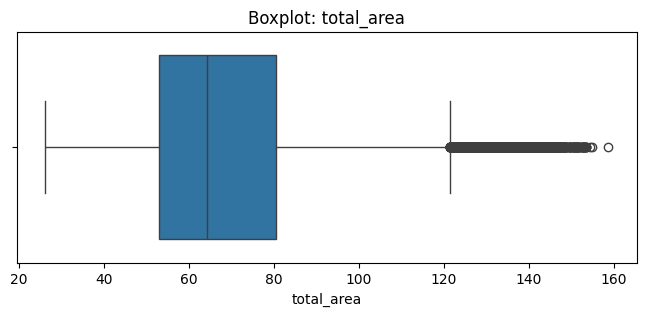

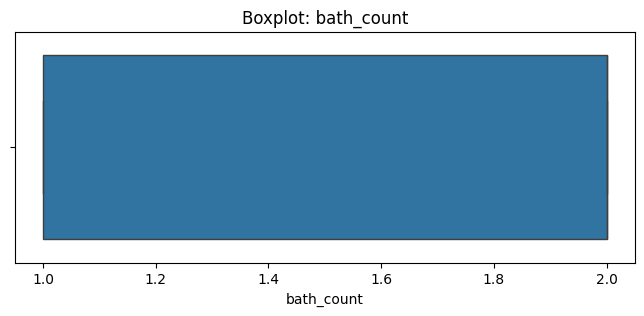

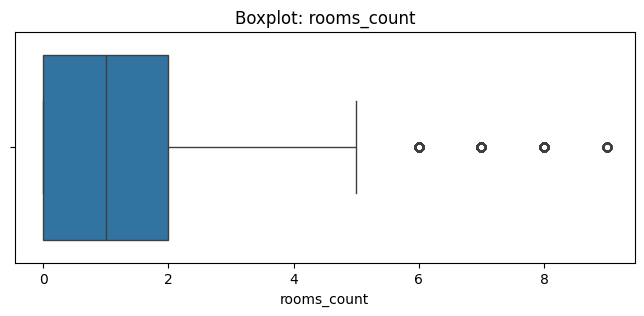

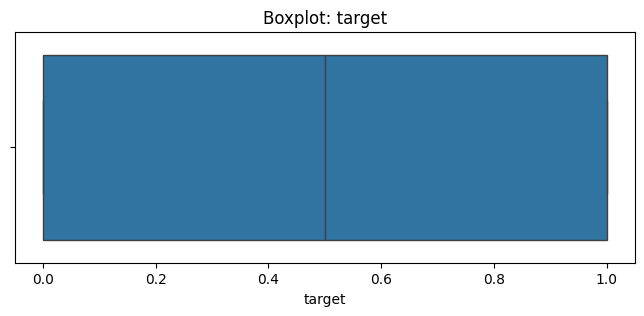

In [26]:
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=train[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

In [28]:
cat_cols = train.select_dtypes(include=["object"]).columns.tolist()
cat_cols

['gas',
 'hot_water',
 'central_heating',
 'extra_area_type_name',
 'district_name']

In [29]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(train[col].value_counts())


--- gas ---
gas
No     50043
Yes    49957
Name: count, dtype: int64

--- hot_water ---
hot_water
Yes    65042
No     34958
Name: count, dtype: int64

--- central_heating ---
central_heating
Yes    89977
No     10023
Name: count, dtype: int64

--- extra_area_type_name ---
extra_area_type_name
loggia     50163
balcony    49837
Name: count, dtype: int64

--- district_name ---
district_name
Moskovskij       14321
Centralnyj       14314
Petrogradskij    14312
Krasnoselskij    14305
Nevskij          14253
Vyborgskij       14251
Kirovskij        14244
Name: count, dtype: int64


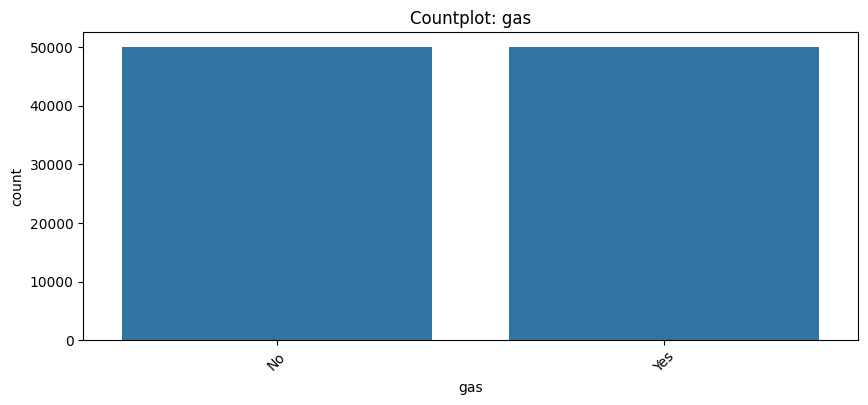

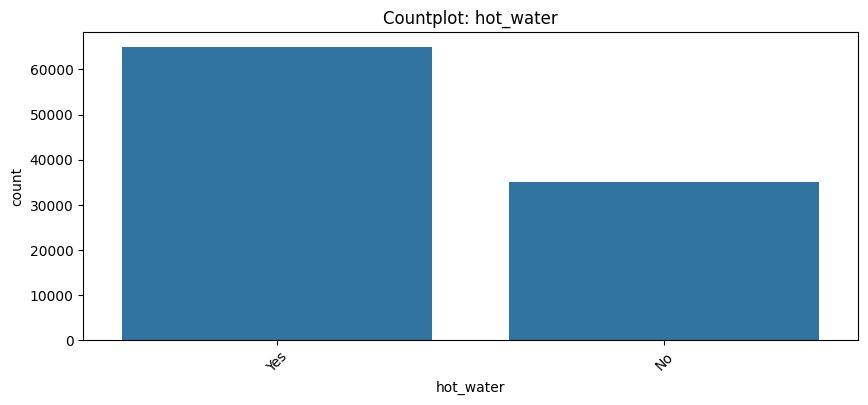

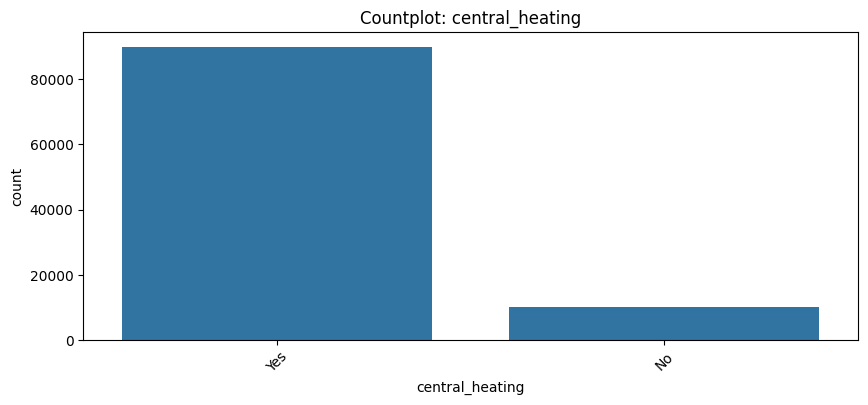

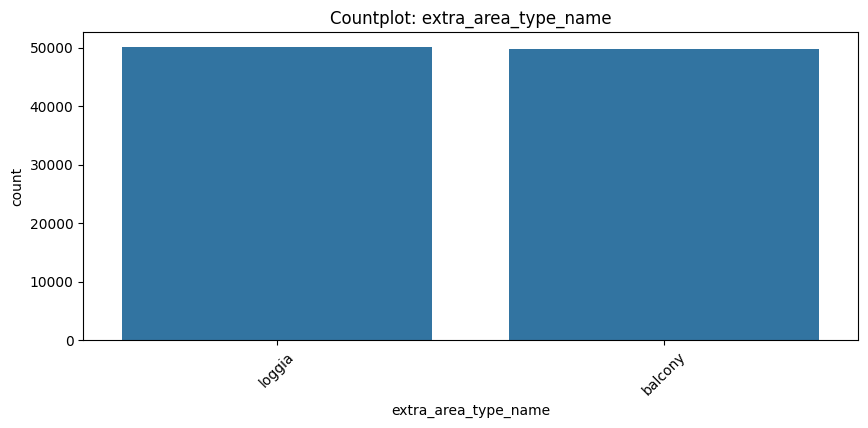

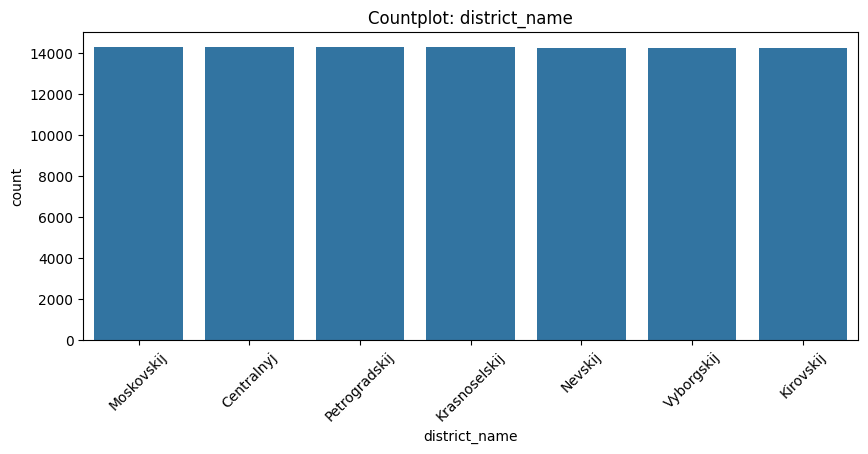

In [30]:
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=train, x=col, order=train[col].value_counts().index)
    plt.title(f"Countplot: {col}")
    plt.xticks(rotation=45)
    plt.show()

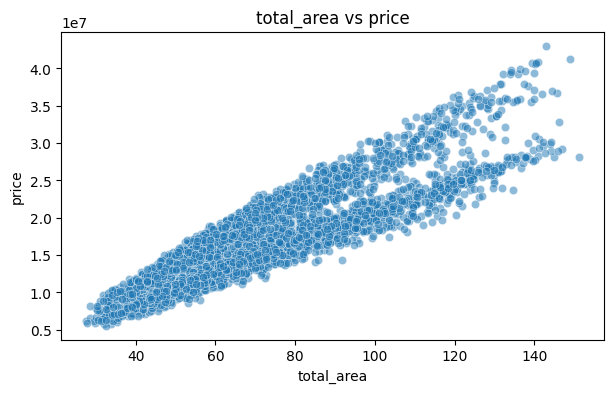

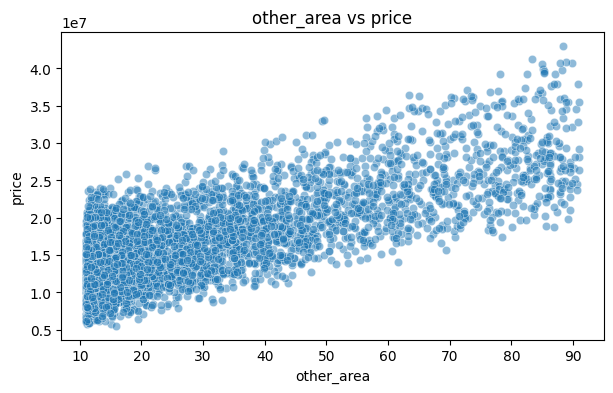

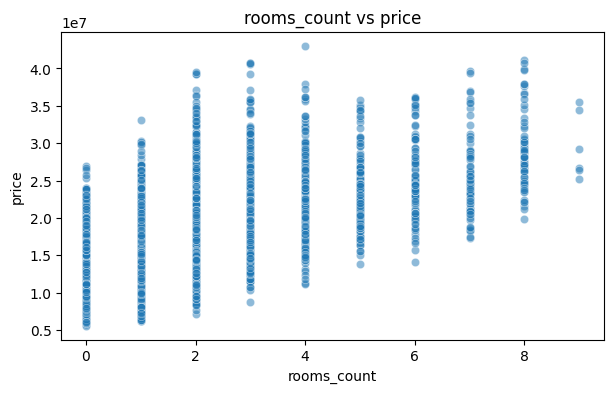

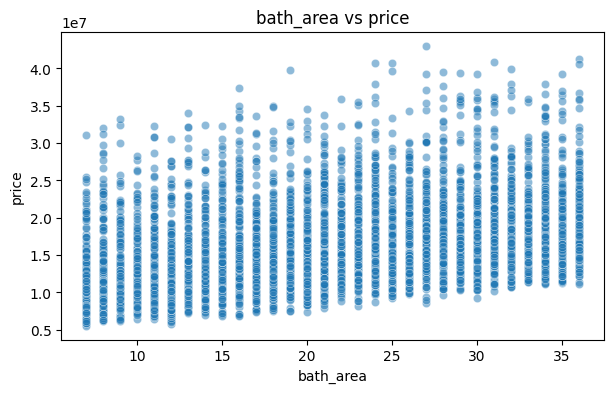

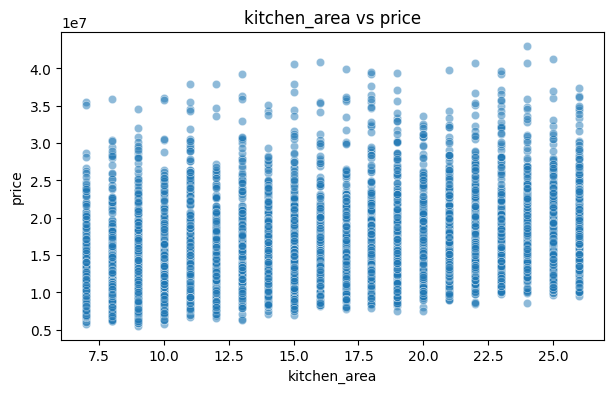

In [31]:
important_num = ["total_area", "other_area", "rooms_count", "bath_area", "kitchen_area"]

for col in important_num:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=train.sample(min(5000, len(train)), random_state=42), x=col, y="price", alpha=0.5)
    plt.title(f"{col} vs price")
    plt.show()

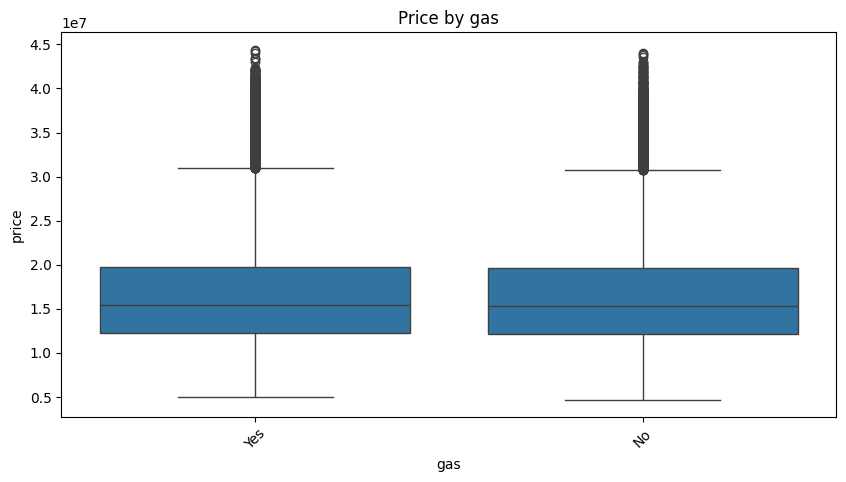

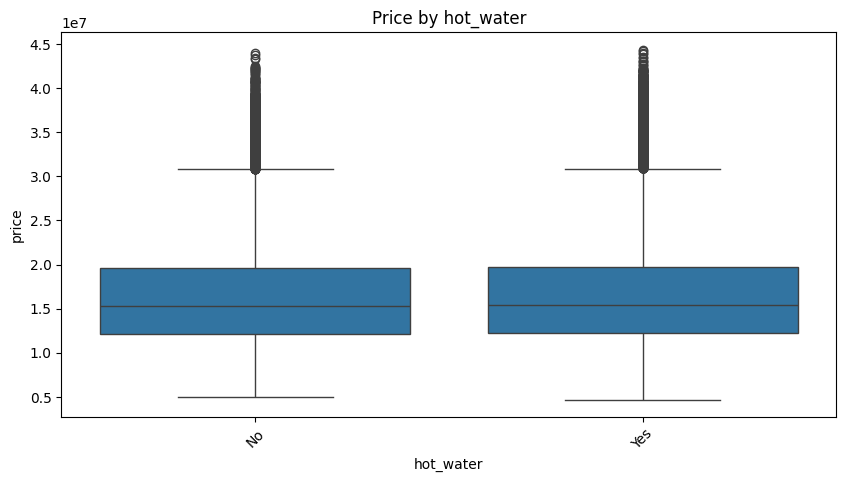

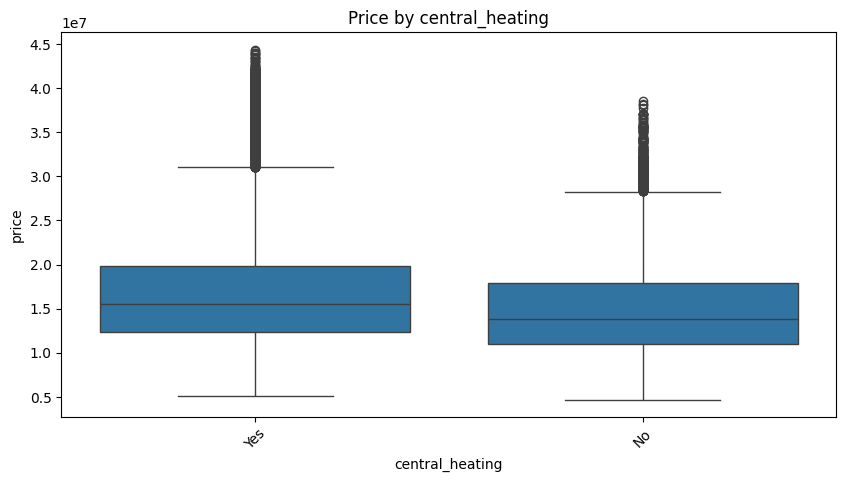

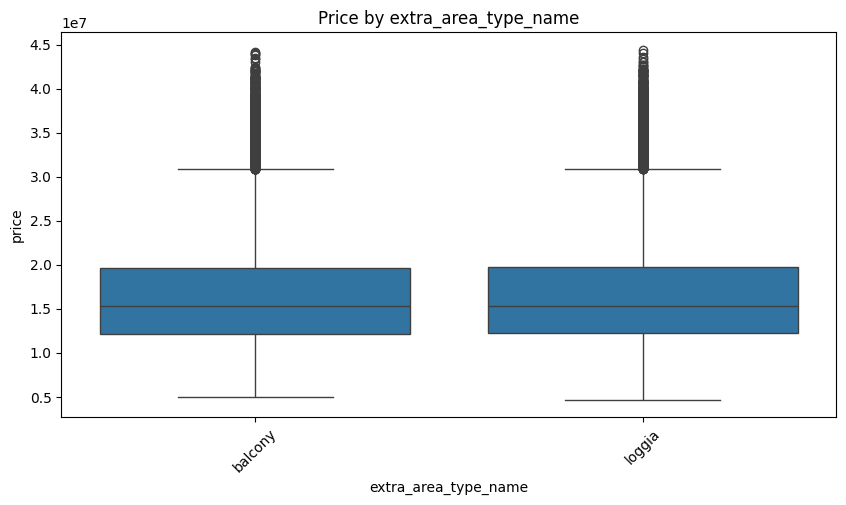

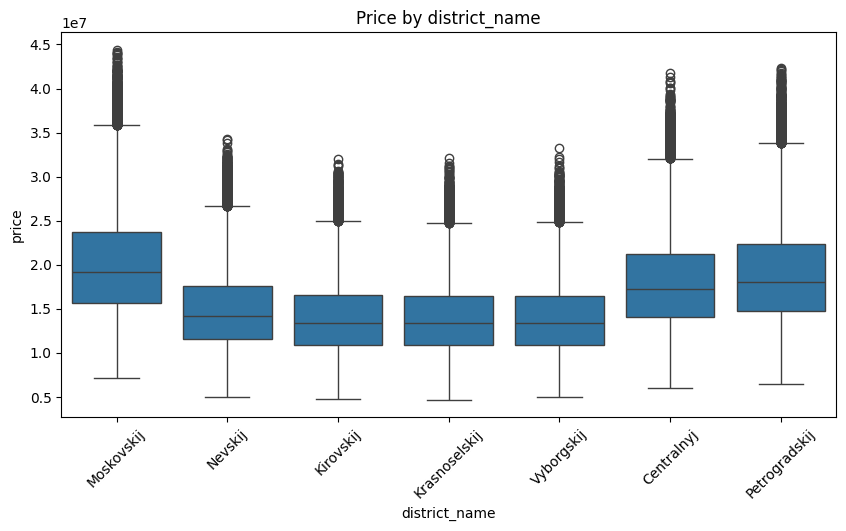

In [32]:
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=train, x=col, y="price")
    plt.title(f"Price by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [33]:
for col in cat_cols:
    stats = train.groupby(col)["price"].agg(["mean", "median", "count"]).sort_values("median", ascending=False)
    print(f"\n=== {col} ===")
    print(stats)


=== gas ===
             mean      median  count
gas                                 
Yes  1.659712e+07  15430172.0  49957
No   1.642722e+07  15288751.0  50043

=== hot_water ===
                   mean      median  count
hot_water                                 
Yes        1.653614e+07  15397534.0  65042
No         1.646737e+07  15284517.5  34958

=== central_heating ===
                         mean      median  count
central_heating                                 
Yes              1.668518e+07  15515954.0  89977
No               1.495830e+07  13853688.0  10023

=== extra_area_type_name ===
                              mean      median  count
extra_area_type_name                                 
loggia                1.654083e+07  15364999.0  50163
balcony               1.648318e+07  15360881.0  49837

=== district_name ===
                       mean      median  count
district_name                                 
Moskovskij     2.034744e+07  19177092.0  14321
Petrogradskij  1.

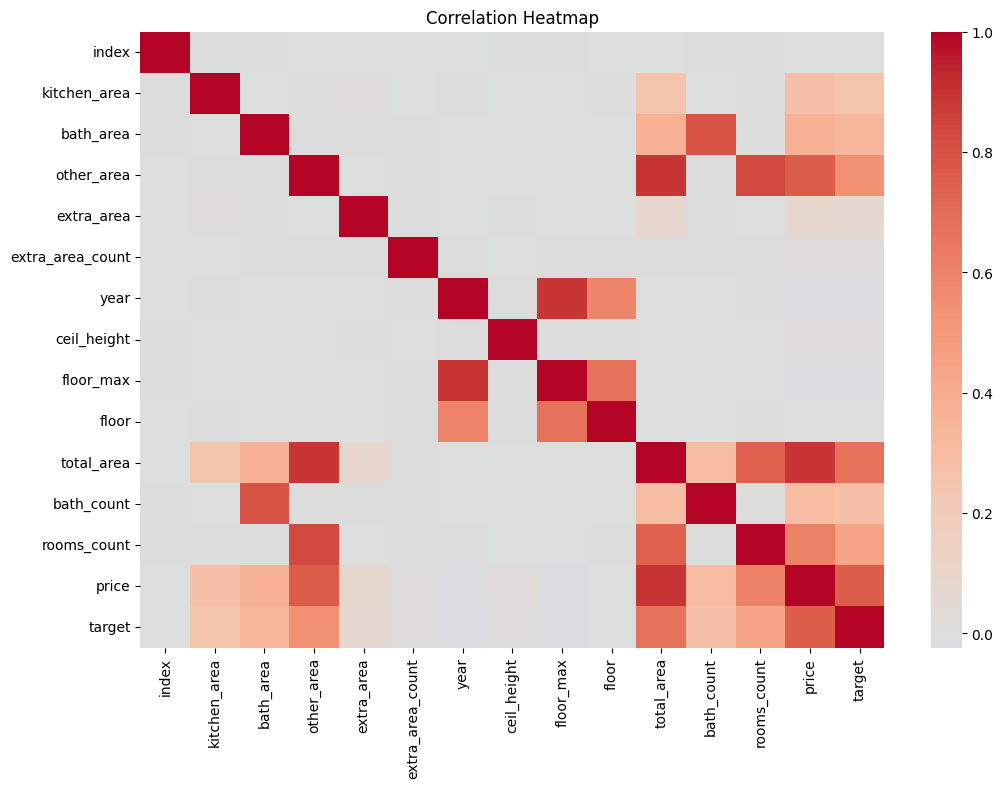

In [34]:
corr = train.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [35]:
corr_with_price = corr["price"].sort_values(ascending=False)
print(corr_with_price)

price               1.000000
total_area          0.888708
target              0.763025
other_area          0.757588
rooms_count         0.616095
bath_area           0.373925
bath_count          0.310200
kitchen_area        0.278471
extra_area          0.080253
ceil_height         0.016679
extra_area_count    0.015273
index              -0.004230
floor              -0.004791
floor_max          -0.022892
year               -0.023307
Name: price, dtype: float64


In [36]:
checks = {
    "negative_kitchen_area": (train["kitchen_area"] < 0).sum(),
    "negative_bath_area": (train["bath_area"] < 0).sum(),
    "negative_other_area": (train["other_area"] < 0).sum(),
    "negative_total_area": (train["total_area"] < 0).sum(),
    "negative_rooms_count": (train["rooms_count"] < 0).sum(),
    "floor_gt_floor_max": (train["floor"] > train["floor_max"]).sum(),
}

checks

{'negative_kitchen_area': np.int64(0),
 'negative_bath_area': np.int64(0),
 'negative_other_area': np.int64(0),
 'negative_total_area': np.int64(0),
 'negative_rooms_count': np.int64(0),
 'floor_gt_floor_max': np.int64(0)}

In [37]:
train["price"].quantile([0.01, 0.05, 0.5, 0.95, 0.99])

0.01     7074730.29
0.05     8815721.20
0.50    15362047.50
0.95    28184277.20
0.99    34849093.71
Name: price, dtype: float64

In [38]:
def clean_data(df):
    df = df.copy()
    
    # удаление дубликатов
    df = df.drop_duplicates().reset_index(drop=True)
    
    # чистка строк
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].astype(str).str.strip()
    
    # защита от нелогичных значений
    if "floor" in df.columns and "floor_max" in df.columns:
        bad_mask = df["floor"] > df["floor_max"]
        df.loc[bad_mask, ["floor", "floor_max"]] = np.nan
    
    # заполнение числовых пропусков медианой
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].fillna(df[col].median())
    
    # заполнение категориальных пропусков
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].fillna("unknown")
    
    return df


train = clean_data(train)
test = clean_data(test)

In [39]:
def add_features(df):
    df = df.copy()
    
    # если total_area уже есть, можно использовать его как основной
    # но также полезно пересчитать дополнительные признаки
    
    df["area_per_room"] = df["total_area"] / (df["rooms_count"] + 1)
    df["bath_per_room"] = df["bath_count"] / (df["rooms_count"] + 1)
    
    df["kitchen_ratio"] = df["kitchen_area"] / (df["total_area"] + 1)
    df["bath_ratio"] = df["bath_area"] / (df["total_area"] + 1)
    df["other_ratio"] = df["other_area"] / (df["total_area"] + 1)
    
    df["is_top_floor"] = (df["floor"] == df["floor_max"]).astype(int)
    df["is_first_floor"] = (df["floor"] == 1).astype(int)
    df["floor_ratio"] = df["floor"] / (df["floor_max"] + 1)
    df["floors_left"] = df["floor_max"] - df["floor"]
    
    df["is_studio"] = (df["rooms_count"] == 0).astype(int)
    df["is_small"] = (df["total_area"] < 40).astype(int)
    df["is_large"] = (df["total_area"] > 100).astype(int)
    
    df["log_total_area"] = np.log1p(df["total_area"])
    df["log_other_area"] = np.log1p(df["other_area"])
    df["total_area_sq"] = df["total_area"] ** 2
    df["rooms_x_area"] = df["rooms_count"] * df["total_area"]
    
    # частотное кодирование района
    district_freq = df["district_name"].value_counts()
    df["district_freq"] = df["district_name"].map(district_freq)
    
    # комбинации категорий
    df["district_gas"] = df["district_name"].astype(str) + "_" + df["gas"].astype(str)
    df["district_heat"] = df["district_name"].astype(str) + "_" + df["central_heating"].astype(str)
    
    return df

In [40]:
train = add_features(train)
test = add_features(test)

In [41]:
TARGET = "price"

X = train.drop(columns=[TARGET])
y = train[TARGET]

X_test = test.copy()

In [43]:
cat_features = X.select_dtypes(include=["object"]).columns.tolist()
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical:", cat_features)
print("Numerical:", len(num_features))

Categorical: ['gas', 'hot_water', 'central_heating', 'extra_area_type_name', 'district_name', 'district_gas', 'district_heat']
Numerical: 31


In [44]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

dummy = DummyRegressor(strategy="mean")
dummy_scores = -cross_val_score(
    dummy,
    X[num_features],   # Dummy работает только с числовыми
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

print("Dummy RMSE:", dummy_scores.mean())

Dummy RMSE: 5977344.043353731


In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

linear_scores = -cross_val_score(
    linear_model,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print("Ridge RMSE:", linear_scores.mean())

Ridge RMSE: 897135.7030237813


In [46]:
rf_model = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ]
    )),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

rf_scores = -cross_val_score(
    rf_model,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print("Random Forest RMSE:", rf_scores.mean())

Random Forest RMSE: 311149.57459616096


In [47]:
y_log = np.log1p(y)

In [49]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)

oof_pred_log = np.zeros(len(X))
test_pred_log = np.zeros(len(X_test))
fold_rmse = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_log.iloc[train_idx], y_log.iloc[val_idx]
    
    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=5,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        early_stopping_rounds=300,
        verbose=300
    )
    
    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_features,
        use_best_model=True
    )
    
    val_pred_log = model.predict(X_val)
    oof_pred_log[val_idx] = val_pred_log
    
    val_pred = np.expm1(val_pred_log)
    val_true = np.expm1(y_val)
    
    score = np.sqrt(mean_squared_error(val_true, val_pred))
    fold_rmse.append(score)
    
    test_pred_log += model.predict(X_test) / kf.n_splits
    
    print(f"Fold {fold} RMSE: {score:.4f}")

print("Mean CV RMSE:", np.mean(fold_rmse))
print("Std CV RMSE:", np.std(fold_rmse))

0:	learn: 0.3412584	test: 0.3374176	best: 0.3374176 (0)	total: 324ms	remaining: 16m 12s


KeyboardInterrupt: 

In [50]:
oof_pred = np.expm1(oof_pred_log)
overall_rmse = np.sqrt(mean_squared_error(y, oof_pred))
print("OOF RMSE:", overall_rmse)

OOF RMSE: 17560732.81289818


In [51]:
results = pd.DataFrame({
    "model": ["DummyRegressor", "Ridge", "RandomForest", "CatBoost"],
    "rmse": [
        dummy_scores.mean(),
        linear_scores.mean(),
        rf_scores.mean(),
        overall_rmse
    ]
})

results.sort_values("rmse")

,model,rmse
2,RandomForest,3.111496e+05
1,Ridge,8.971357e+05
0,DummyRegressor,5.977344e+06
3,CatBoost,1.756073e+07


In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y, oof_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.show()

In [ ]:
residuals = y - oof_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution")
plt.show()

In [ ]:
error_df = pd.DataFrame({
    "actual": y,
    "pred": oof_pred,
    "abs_error": np.abs(y - oof_pred)
})

error_df["price_bin"] = pd.qcut(error_df["actual"], q=5)

error_by_bin = error_df.groupby("price_bin")["abs_error"].mean()
print(error_by_bin)

In [ ]:
analysis_df = train.copy()
analysis_df["pred_price"] = oof_pred
analysis_df["abs_error"] = np.abs(analysis_df["price"] - analysis_df["pred_price"])

district_error = analysis_df.groupby("district_name")["abs_error"].mean().sort_values(ascending=False)
print(district_error)

In [ ]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.get_feature_importance()
}).sort_values("importance", ascending=False)

feature_importance.head(20)

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x="importance", y="feature")
plt.title("Top-15 Feature Importances")
plt.show()

In [ ]:
final_model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=300
)

final_model.fit(
    X,
    y_log,
    cat_features=cat_features
)

In [ ]:
test_pred_log_final = final_model.predict(X_test)
test_pred_final = np.expm1(test_pred_log_final)

submission = sample_sub.copy()
submission.iloc[:, 1] = test_pred_final
submission.to_csv("my_submission.csv", index=False)

print("Submission saved: my_submission.csv")